# California Housing Price Prediction

Predicting median house values across California districts using demographic and geographic data.

**Problem:** Real estate firms need a reliable way to estimate property values from basic district-level stats (income, location, household size) instead of relying on manual appraisal for every listing.

**Approach:** Train and compare several regression models, tune the best one, and check which features actually drive the price.

**Target:** `MedHouseVal` — median house value for a district (in $100,000s)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

sns.set_style("whitegrid")
RANDOM_STATE = 42


## Dataset

Built-in scikit-learn California Housing dataset — 20,640 rows, one row per census block group.

| Feature | Meaning |
|---|---|
| MedInc | Median income in the block group (tens of thousands) |
| HouseAge | Median house age |
| AveRooms | Average rooms per household |
| AveBedrms | Average bedrooms per household |
| Population | Block group population |
| AveOccup | Average household size |
| Latitude / Longitude | Location |

Target: `MedHouseVal`


In [3]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["MedHouseVal"] = housing.target

df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Data Quality Check

Before doing anything else — shape, duplicates, missing values, and a quick statistical summary.


In [4]:
print(f"Shape: {df.shape}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print("\nMissing values per column:")
print(df.isnull().sum())


Shape: (20640, 9)
Duplicate rows: 0

Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [5]:
df.describe()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


No missing values, no duplicates — this dataset is already fairly clean, so we can move straight to exploring it.

## Exploratory Data Analysis


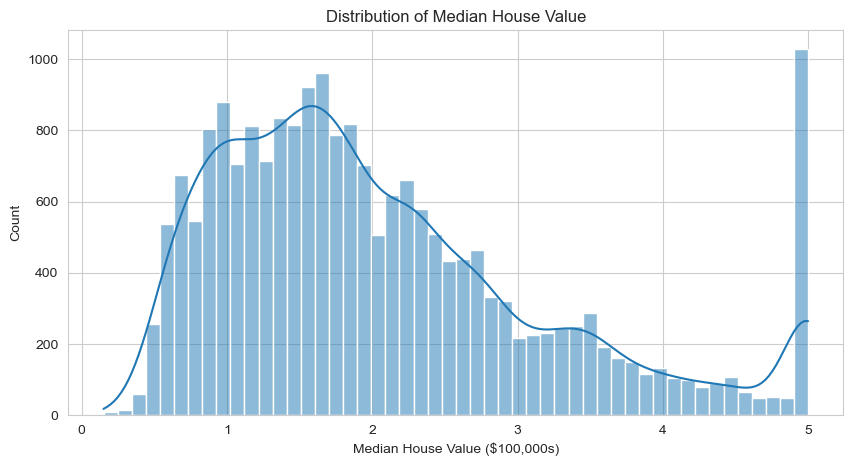

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df["MedHouseVal"], bins=50, kde=True)
plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value ($100,000s)")
plt.ylabel("Count")
plt.show()


The target is right-skewed with a hard cap around 5.0 — the dataset caps house values at $500,000, so anything above that gets clipped to the same number. Worth keeping in mind when we look at outliers later.


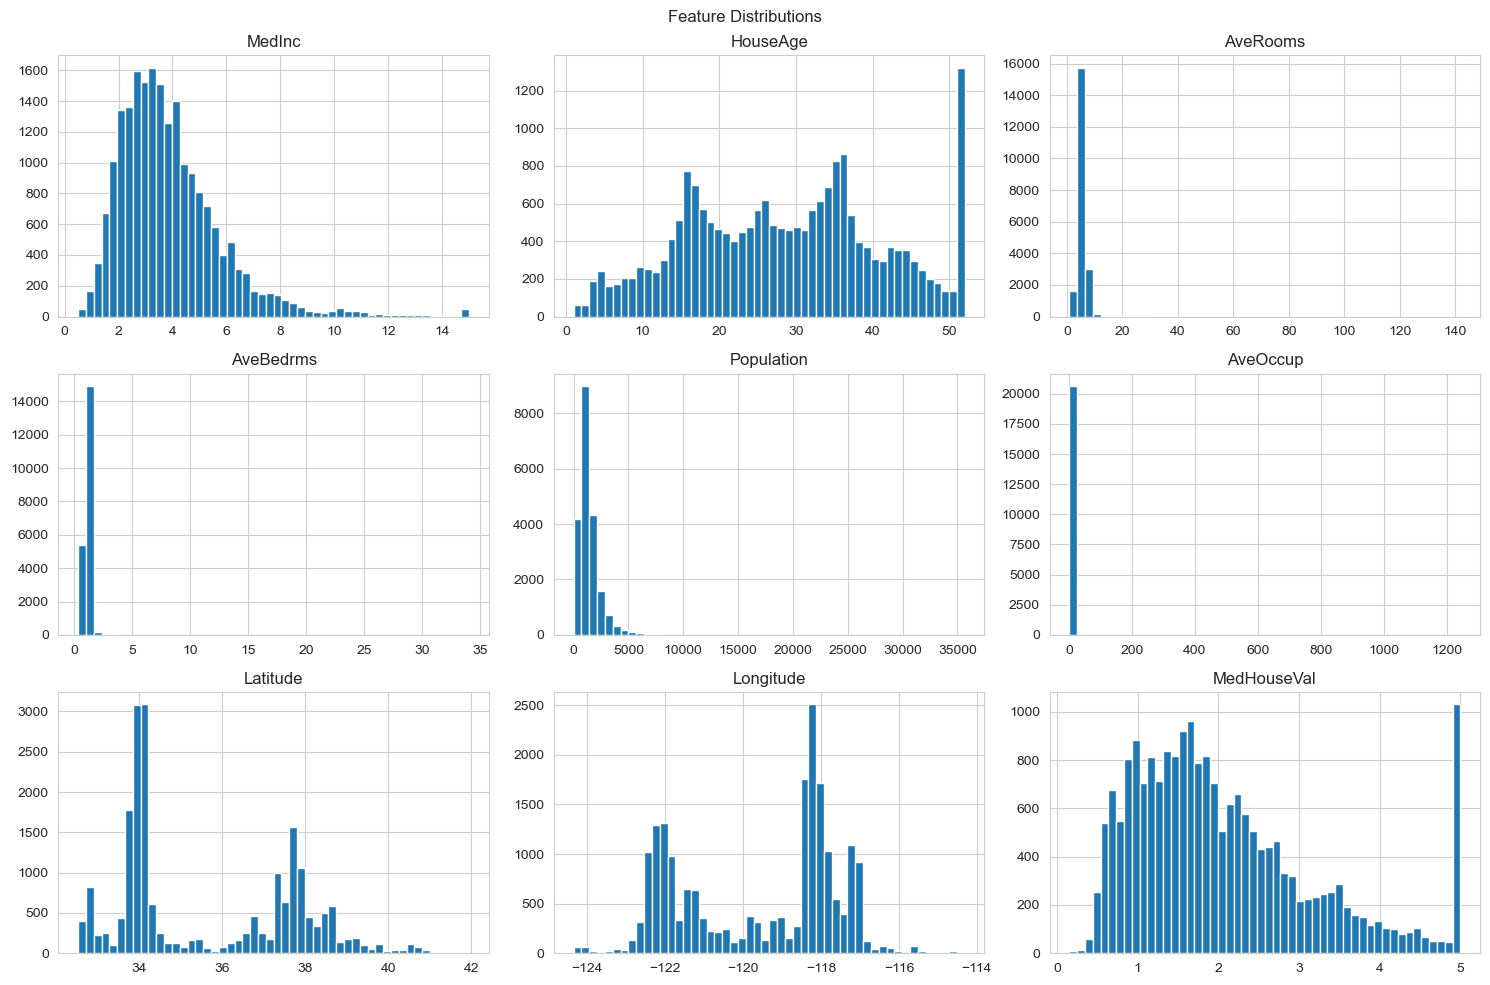

In [7]:
df.hist(bins=50, figsize=(15, 10))
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()


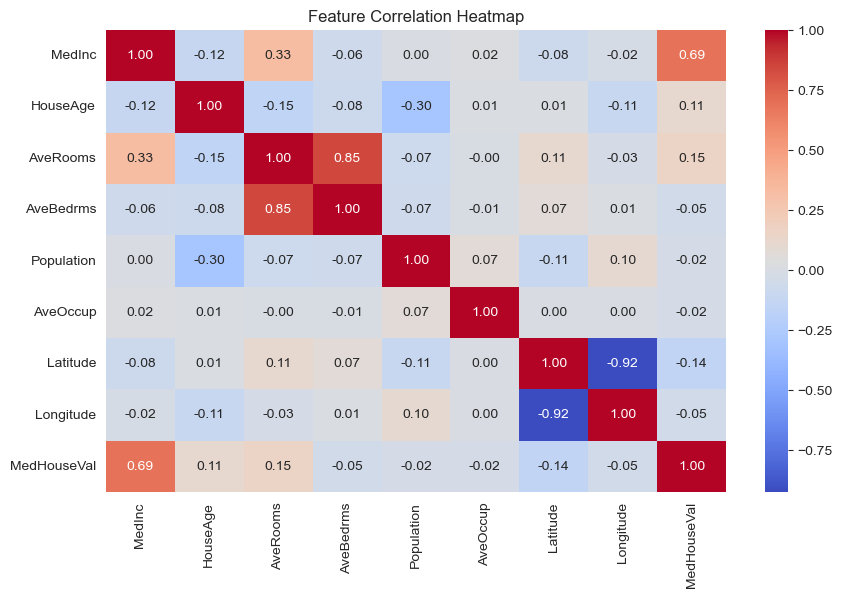

In [8]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


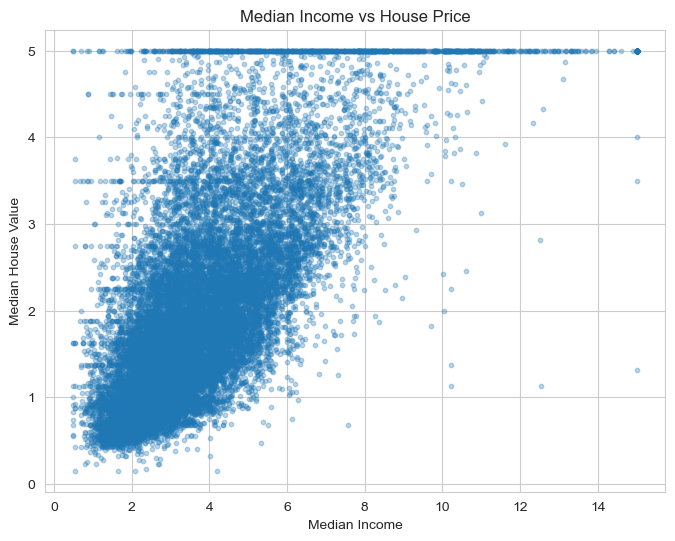

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(df["MedInc"], df["MedHouseVal"], alpha=0.3, s=10)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs House Price")
plt.show()


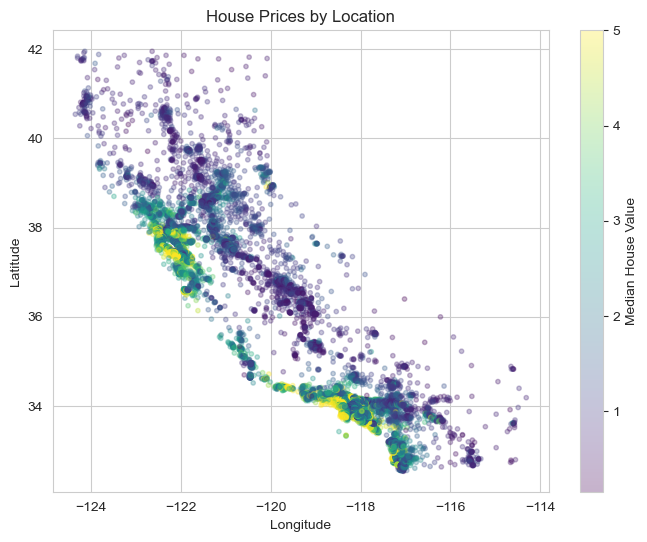

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(df["Longitude"], df["Latitude"], alpha=0.3, s=10, c=df["MedHouseVal"], cmap="viridis")
plt.colorbar(label="Median House Value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("House Prices by Location")
plt.show()


Coloring by price makes this one actually useful — you can see the coastal strip (LA, Bay Area) light up compared to inland districts, which lines up with the correlation we're seeing on Latitude/Longitude below.


In [11]:
df.corr()["MedHouseVal"].sort_values(ascending=False)


MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

**Median income is by far the strongest predictor**, which makes intuitive sense — higher-earning areas can afford (and bid up) pricier housing. Latitude also shows a meaningful negative correlation, tied to the coastal-vs-inland pattern above.

## Feature Engineering

Raw counts like `AveRooms` or `Population` aren't that meaningful on their own — a district can have big households and big houses without being wealthy. Ratios tend to capture more signal:

- `rooms_per_household` — house size relative to household size
- `bedrooms_per_room` — how "bedroom-heavy" a house is (lower can mean more living space)
- `population_per_household` — a rough density measure


In [12]:
df["rooms_per_household"] = df["AveRooms"] / df["AveOccup"]
df["bedrooms_per_room"] = df["AveBedrms"] / df["AveRooms"]
df["population_per_household"] = df["Population"] / df["AveOccup"]

df[["rooms_per_household", "bedrooms_per_room", "population_per_household"]].describe()


,rooms_per_household,bedrooms_per_room,population_per_household
count,20640.000000,20640.000000,20640.000000
mean,1.976970,0.213075,499.539680
std,1.146020,0.058023,382.329753
min,0.002547,0.100000,1.000000
25%,1.522382,0.175426,280.000000
50%,1.937936,0.203181,409.000000
75%,2.296090,0.239834,605.000000
max,55.222222,1.000000,6082.000000


## Train / Test Split


In [13]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


Train size: 16512, Test size: 4128


## Baseline Model — Linear Regression

Starting simple so we have something to actually beat.


In [14]:
baseline = LinearRegression()
baseline.fit(X_train, y_train)
baseline_preds = baseline.predict(X_test)

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))
baseline_r2 = r2_score(y_test, baseline_preds)

print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Baseline R2:   {baseline_r2:.4f}")


Baseline RMSE: 0.6738
Baseline R2:   0.6535


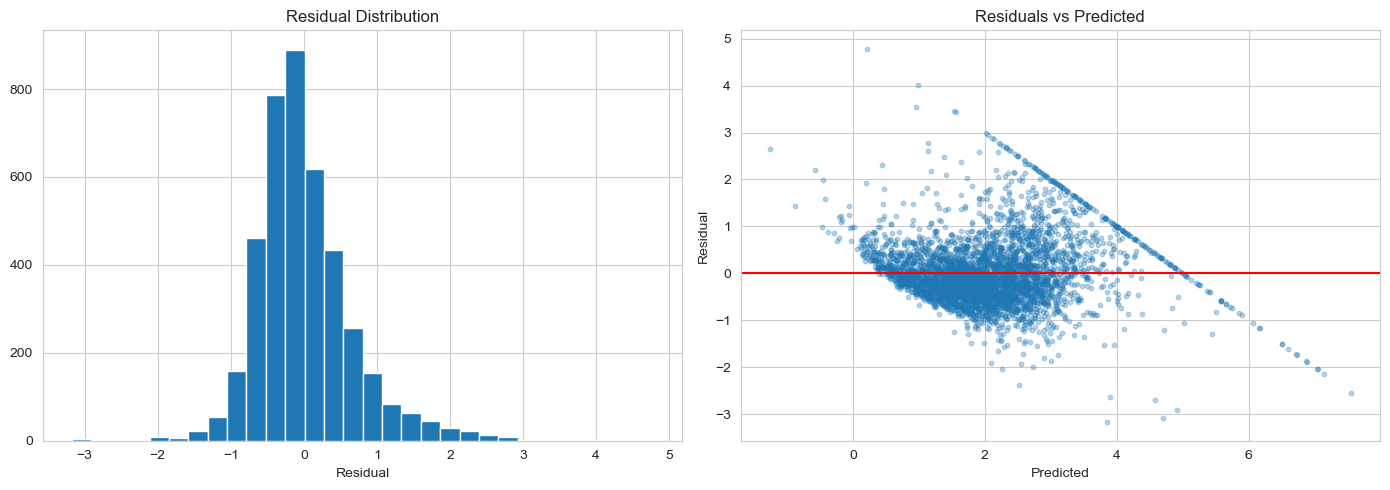

In [15]:
residuals = y_test - baseline_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals, bins=30)
axes[0].set_title("Residual Distribution")
axes[0].set_xlabel("Residual")

axes[1].scatter(baseline_preds, residuals, alpha=0.3, s=10)
axes[1].axhline(0, color="red")
axes[1].set_title("Residuals vs Predicted")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residual")

plt.tight_layout()
plt.show()


There's a visible pattern at the high end — residuals fan out and skew for the most expensive districts, likely the $500k cap distorting things. Linear regression isn't capturing the non-linear relationships here, which is exactly what the next step is for.

## Comparing Multiple Models

Same train/test split, same evaluation, run through a handful of different model types so it's a fair comparison.


In [16]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    return {"Model": name, "RMSE": round(rmse, 4), "R2": round(r2, 4)}


candidate_models = {
    "Linear Regression": LinearRegression(),
    "SVR": SVR(),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

results = [
    evaluate_model(name, model, X_train, X_test, y_train, y_test)
    for name, model in candidate_models.items()
]

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df


,Model,RMSE,R2
3,Random Forest,0.5060,0.8046
4,Gradient Boosting,0.5384,0.7788
1,SVR,0.5650,0.7564
0,Linear Regression,0.6738,0.6535
2,Decision Tree,0.7130,0.6121


## Cross Validation

Single train/test split can be a bit lucky or unlucky — cross-validating the strongest-looking model (Random Forest) gives a more honest read on how it'll generalize.


In [18]:
rf = RandomForestRegressor(random_state=RANDOM_STATE)

cv_scores = cross_val_score(
    rf, X_train, y_train,
    scoring="neg_mean_squared_error",
    cv=10 )
cv_rmse = np.sqrt( -cv_scores )

print(f"CV RMSE scores: {np.round( cv_rmse, 4 )}" )
print(f"Mean CV RMSE: {cv_rmse.mean():.4f} (+/- {cv_rmse.std():.4f})")


CV RMSE scores: [0.4871 0.5255 0.5038 0.522  0.5265 0.4845 0.496  0.5149 0.5028 0.518 ]
Mean CV RMSE: 0.5081 (+/- 0.0147)


## Hyperparameter Tuning

Grid search over the Random Forest's main knobs — tree count, depth, and split threshold.


In [ ]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")


## Final Evaluation

Running the tuned model against the held-out test set — the numbers that actually matter.


In [ ]:
final_preds = best_model.predict(X_test)

final_rmse = np.sqrt(mean_squared_error(y_test, final_preds))
final_r2 = r2_score(y_test, final_preds)

print(f"Final RMSE: {final_rmse:.4f}")
print(f"Final R2:   {final_r2:.4f}")


In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, final_preds, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", label="Perfect prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted — Tuned Random Forest")
plt.legend()
plt.show()


## Feature Importance


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance)
plt.title("Feature Importance — Random Forest")
plt.tight_layout()
plt.show()

feature_importance


## Model Comparison Summary

Adding the tuned model's numbers to the earlier comparison table so everything's in one place.


In [ ]:
summary_df = pd.concat([
    results_df,
    pd.DataFrame([{"Model": "Random Forest (tuned)", "RMSE": round(final_rmse, 4), "R2": round(final_r2, 4)}])
], ignore_index=True).sort_values("RMSE").reset_index(drop=True)

summary_df


## Business Interpretation

- **Median income dominates.** It's the single strongest driver of house value in this dataset — no surprise, but good to have it confirmed numerically rather than assumed.
- **Location matters almost as much as income.** Coastal, high-income metro areas (LA, SF Bay) consistently pull prices up regardless of house size.
- **Household size ratios (rooms/bedrooms per household) add smaller but real signal** — they help the model separate "big house, few people" (likely wealthier) from "big house, many people" (likely just a larger family).

For a real estate business, this suggests appraisal models should weight income and location data heavily and treat raw square-footage-style features as secondary adjustments, not primary drivers.

## Conclusion

Random Forest (tuned) gave the best balance of RMSE and R² among everything tested here, consistent with what tree ensembles usually do well on tabular data with non-linear feature interactions.

**Possible next steps:**
- Try XGBoost / LightGBM for a stronger boosting baseline
- Add engineered location features (distance to nearest coast, distance to major city centers)
- Log-transform the target to reduce the effect of the $500k value cap
- Wrap the final pipeline in a small Streamlit app for interactive predictions

## Saving the Model


In [ ]:
joblib.dump(best_model, "housing_model.pkl")
print("Saved best_model to housing_model.pkl")
